In [2]:
import pandas as pd

# Target Survived 
df = pd.read_csv("../data/clean_titanic_dataset.csv")

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


# Outlier Handling

| **Feature** | **IQR (Interquartile Range)** | **Z-Score** |
| ------------------------------------------- | ---------------------------------------------------- | -------------------------------------------------------- |
| Statistical Basis | Medians and Percentiles (Q1 and Q3) | Mean (μ) and Standard Deviation (σ) |
| Data Assumption | Distribution-free (works on skewed data) | Assumes a Normal Distribution |
| Sensitivity to Outliers | Robust; extreme values do not distort the boundaries | Sensitive; extreme outliers distort the mean itself |
| Outlier Threshold | Outside $[Q1 - 1.5(IQR),\ Q3 + 1.5(IQR)]$ | Typically $|z| > 3$ |
| Output Type | Fences/boundaries (identifies inside vs. outside) | A continuous standardized score for every point |

# Using IQR

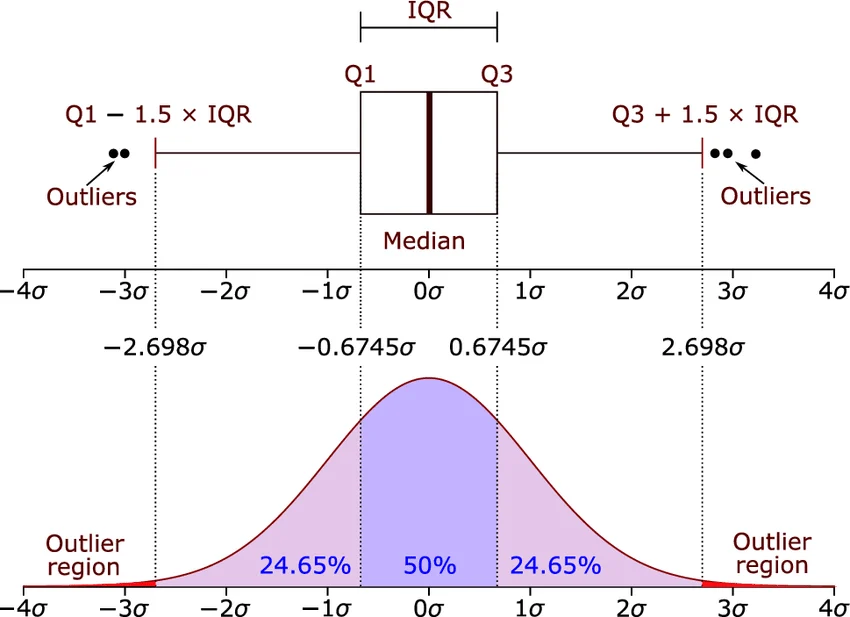

In [4]:
Q1 = df.Age.quantile(q= 0.25)
Q3 = df.Age.quantile(q= 0.75)

IQR = Q3 - Q1

maximum = Q3 + (1.5 * IQR)
minimum = Q1 - (1.5 * IQR)

print(minimum, maximum)

0.0 56.0


In [5]:
df[(df.Age > maximum) | (df.Age < minimum)].shape

(34, 12)

In [6]:
df_outlier_age = df[(df.Age <= maximum) | (df.Age >= minimum)]
df_outlier_age.shape

(889, 12)

In [7]:
df_outlier_age.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


# Outlier of Fare

<Axes: >

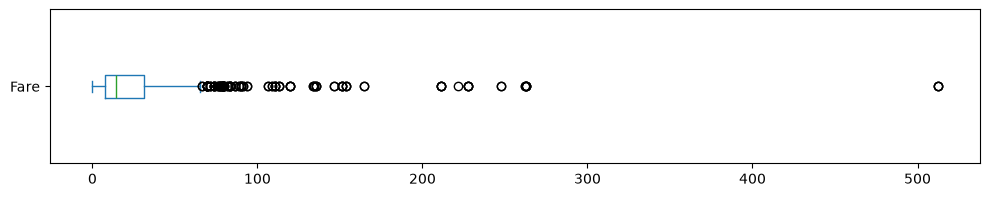

In [8]:
df.Fare.plot(
    kind= 'box',
    vert= False,
    figsize= (12, 2)
)

In [10]:
Q1 = df.Fare.quantile(q=0.25)
Q3 = df.Fare.quantile(q=0.75)

IQR = Q3 - Q1

maximum = Q3 + (1.5 * IQR)
minimum = Q1 - (1.5 * IQR)

print(minimum, maximum)

-26.7605 65.6563
